# 03 — Model Training & Evaluation

**Project:** Network Intrusion Detection using ML with Explainable AI  
**Program:** IEEE CS Bangalore Chapter — SIMP 2026  
**Team:** Piyush M. Borkar, Varun Gada

---

### Models Trained
| Type | Model | Task |
|------|-------|------|
| ML | Random Forest | Binary + Multiclass |
| ML | XGBoost | Binary + Multiclass |
| ML | Decision Tree | Binary + Multiclass |
| ML | Logistic Regression | Binary + Multiclass |
| DL | MLP (Deep Neural Net) | Binary + Multiclass |
| DL | Autoencoder | Anomaly Detection |

## 1. Imports & Setup

In [1]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
CM_DIR    = os.path.join(BASE_DIR, 'results', 'confusion_matrix')
FI_DIR    = os.path.join(BASE_DIR, 'results', 'feature_importance')
GRAPH_DIR = os.path.join(BASE_DIR, 'results', 'graphs')
MODEL_DIR = os.path.join(BASE_DIR, 'results', 'models')
for d in [CM_DIR, FI_DIR, GRAPH_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)
print('Setup complete.')

TensorFlow: 2.21.0
GPU available: False
Setup complete.


## 2. Load Processed Data

In [2]:
df_train = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'train_cleaned.csv'))
df_test  = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'test_cleaned.csv'))
print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)

Train shape: (125973, 125)
Test shape : (22544, 125)


## 3. Feature Preparation

In [3]:
DROP_COLS    = ['label', 'attack_category', 'binary_label']
FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]

X_train_raw = df_train[FEATURE_COLS].values
X_test_raw  = df_test[FEATURE_COLS].values

y_train_bin = df_train['binary_label'].values
y_test_bin  = df_test['binary_label'].values

le = LabelEncoder()
y_train_multi = le.fit_transform(df_train['attack_category'])
test_mask     = df_test['attack_category'] != 'Unknown'
X_test_multi_raw = X_test_raw[test_mask]
y_test_multi  = le.transform(df_test['attack_category'][test_mask])
CLASS_NAMES   = le.classes_

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
X_test_multi = scaler.transform(X_test_multi_raw)

with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'wb') as f: pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'wb') as f: pickle.dump(le, f)
with open(os.path.join(MODEL_DIR, 'feature_cols.pkl'), 'wb') as f: pickle.dump(FEATURE_COLS, f)

print(f'Features      : {len(FEATURE_COLS)}')
print(f'Train samples : {X_train.shape[0]}')
print(f'Classes       : {CLASS_NAMES}')
print(f'Unknown rows excluded from multiclass test: {(~test_mask).sum()}')

Features      : 122
Train samples : 125973
Classes       : ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']
Unknown rows excluded from multiclass test: 2


## 4. Helper Functions

In [4]:
def evaluate(name, y_true, y_pred, class_names, task='binary'):
    avg = 'binary' if task == 'binary' else 'weighted'
    m   = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred)*100, 2),
        'Precision': round(precision_score(y_true, y_pred, average=avg, zero_division=0)*100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, average=avg, zero_division=0)*100, 2),
        'F1'       : round(f1_score(y_true, y_pred, average=avg, zero_division=0)*100, 2),
    }
    print(f'\n── {name} ({task}) ──')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return m

def save_cm(y_true, y_pred, class_names, title, path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(6, len(class_names)*2), max(5, len(class_names)*1.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.4, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title, fontweight='bold')
    plt.tight_layout(); plt.savefig(path, bbox_inches='tight'); plt.show()

def save_fi(model, feature_names, title, path, top=20):
    imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(top)
    fig, ax = plt.subplots(figsize=(10, 5))
    imp.plot(kind='bar', ax=ax, color=sns.color_palette('Set2')[0], edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Importance'); ax.tick_params(axis='x', rotation=60)
    plt.tight_layout(); plt.savefig(path, bbox_inches='tight'); plt.show()

def save_model(obj, name):
    path = os.path.join(MODEL_DIR, f'{name}.pkl')
    with open(path, 'wb') as f: pickle.dump(obj, f)
    print(f'Saved: {path}')

ES = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print('Helpers defined.')

Helpers defined.


---
## 5. ML Models — Binary Classification

Training Random Forest...

── Random Forest (binary) ──
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



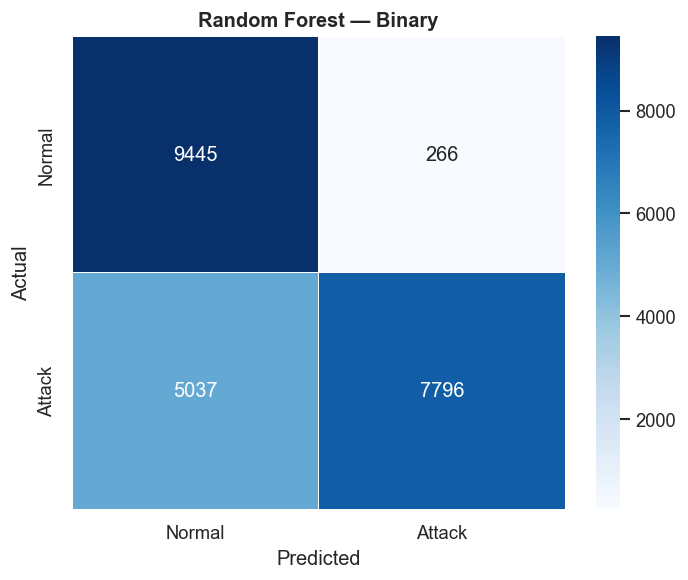

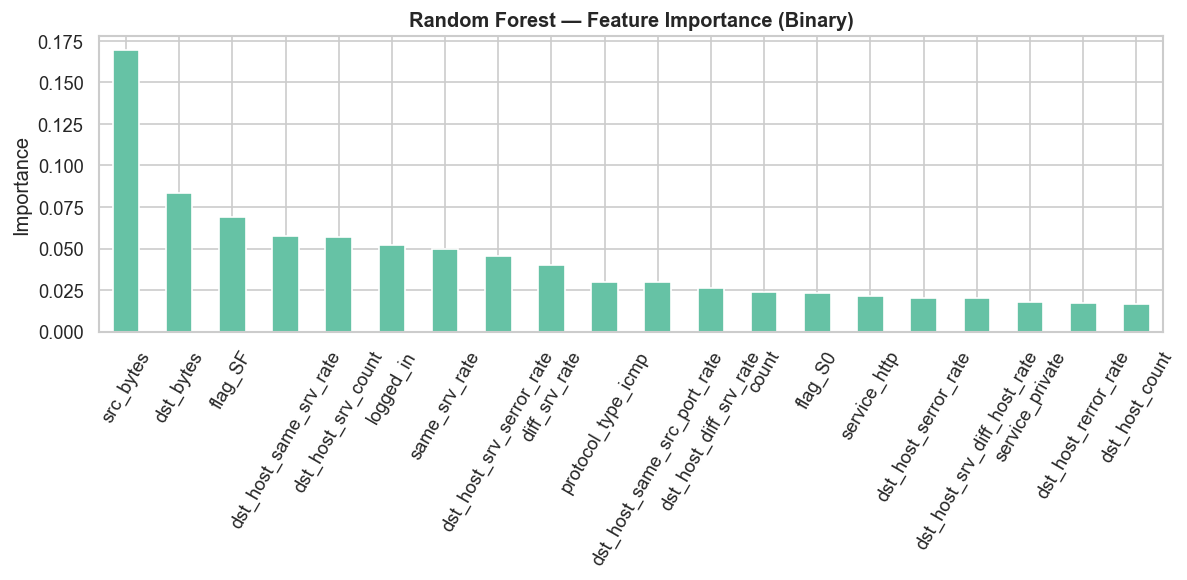

Saved: d:\projects\network-intrusion-detection-xai\results\models\random_forest_binary.pkl
Training XGBoost...

── XGBoost (binary) ──
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
      Attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



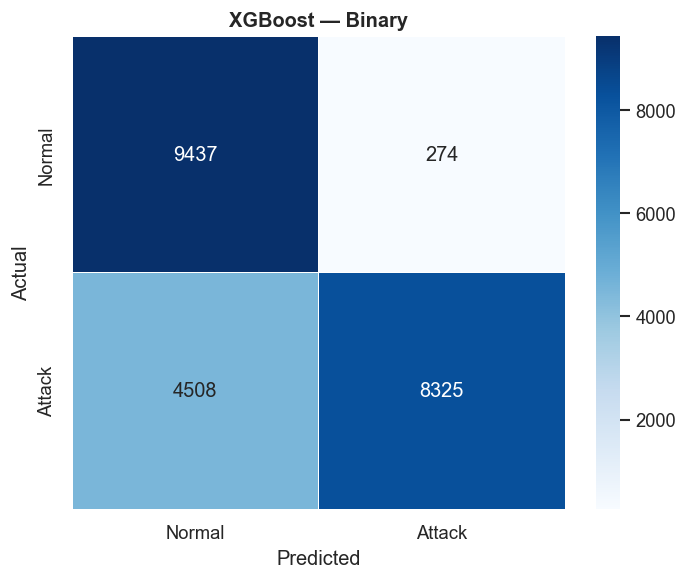

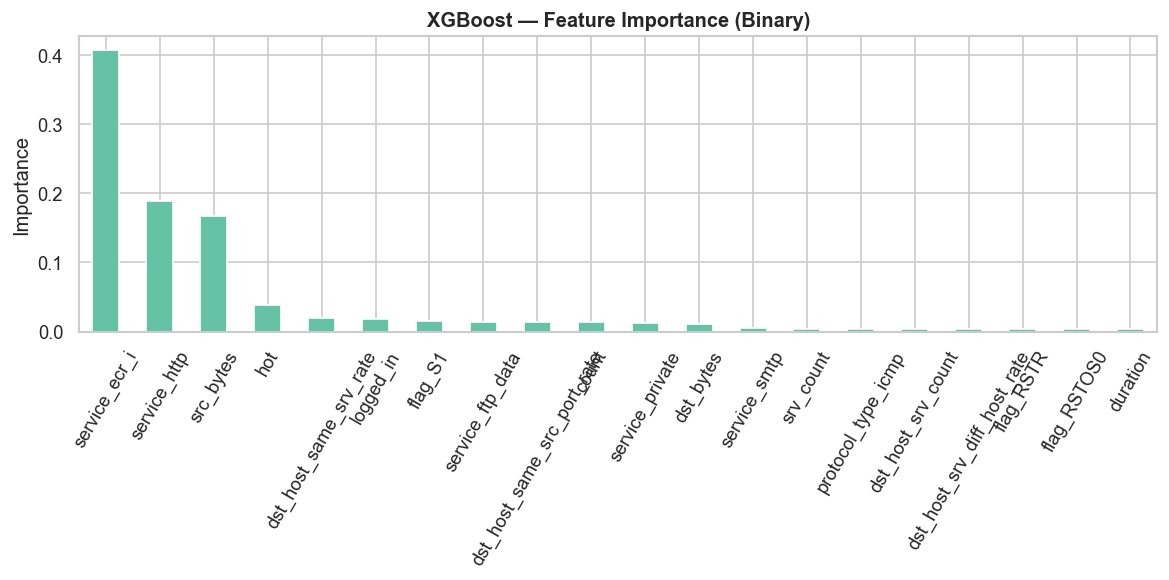

Saved: d:\projects\network-intrusion-detection-xai\results\models\xgboost_binary.pkl
Training Decision Tree...

── Decision Tree (binary) ──
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
      Attack       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



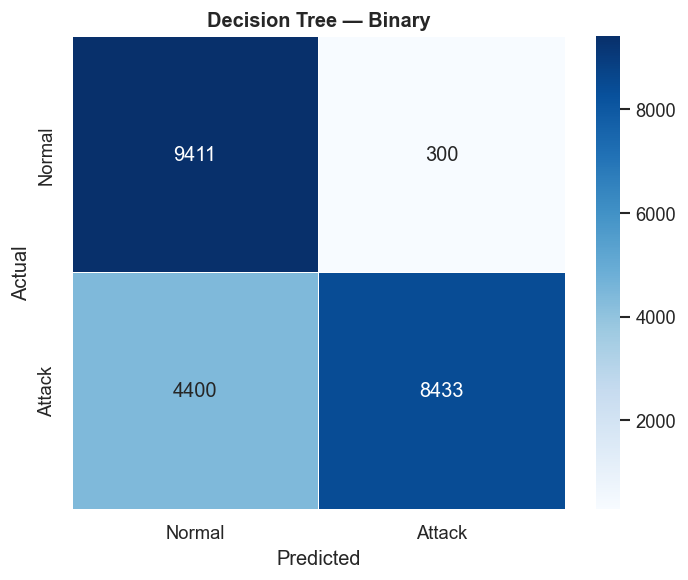

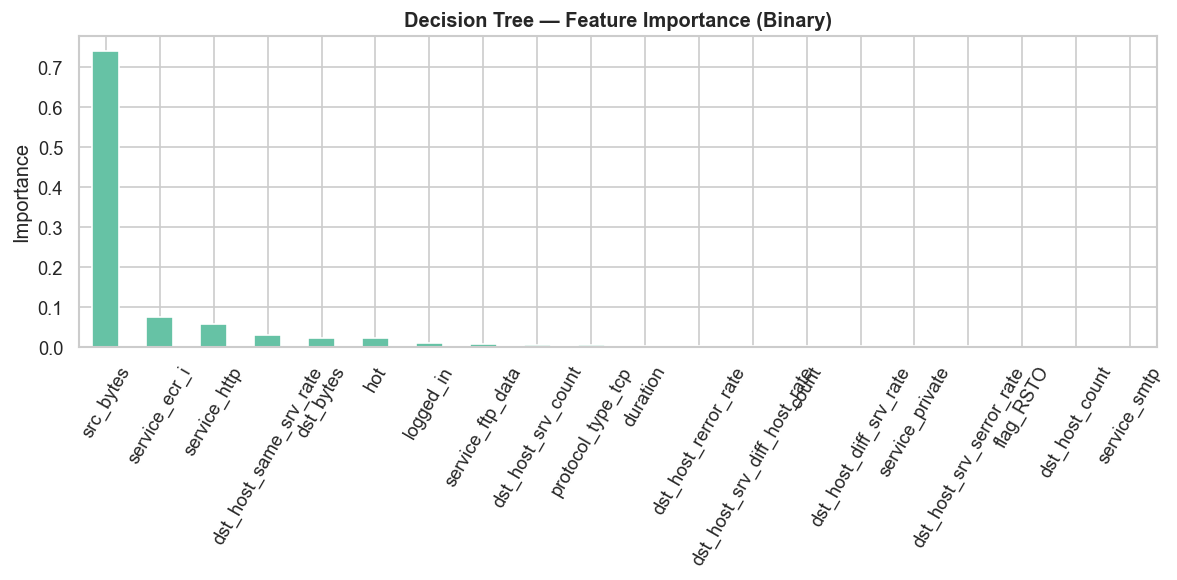

Saved: d:\projects\network-intrusion-detection-xai\results\models\decision_tree_binary.pkl
Training Logistic Regression...

── Logistic Regression (binary) ──
              precision    recall  f1-score   support

      Normal       0.65      0.93      0.76      9711
      Attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



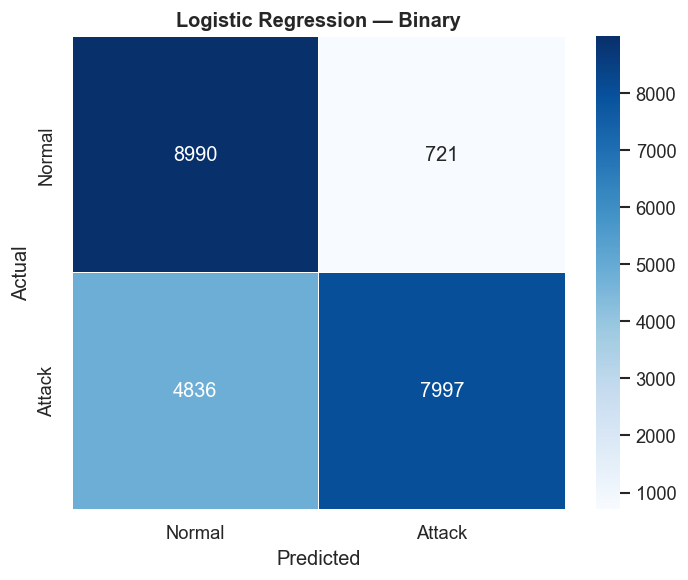

Saved: d:\projects\network-intrusion-detection-xai\results\models\logistic_regression_binary.pkl


In [5]:
BIN_CLASSES = ['Normal', 'Attack']
ml_bin_results = []

ml_models_bin = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

for name, model in ml_models_bin.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_bin)
    y_pred = model.predict(X_test)
    ml_bin_results.append(evaluate(name, y_test_bin, y_pred, BIN_CLASSES, 'binary'))
    save_cm(y_test_bin, y_pred, BIN_CLASSES, f'{name} — Binary',
            os.path.join(CM_DIR, f'cm_{name.lower().replace(" ","_")}_binary.png'))
    if hasattr(model, 'feature_importances_'):
        save_fi(model, FEATURE_COLS, f'{name} — Feature Importance (Binary)',
                os.path.join(FI_DIR, f'fi_{name.lower().replace(" ","_")}_binary.png'))
    save_model(model, f'{name.lower().replace(" ","_")}_binary')

## 6. ML Models — Multiclass Classification

Training Random Forest...

── Random Forest (multiclass) ──
              precision    recall  f1-score   support

         DoS       0.96      0.80      0.87      7458
      Normal       0.65      0.97      0.78      9711
       Probe       0.81      0.60      0.69      2421
         R2L       0.95      0.02      0.04      2885
         U2R       0.33      0.01      0.03        67

    accuracy                           0.75     22542
   macro avg       0.74      0.48      0.48     22542
weighted avg       0.81      0.75      0.70     22542



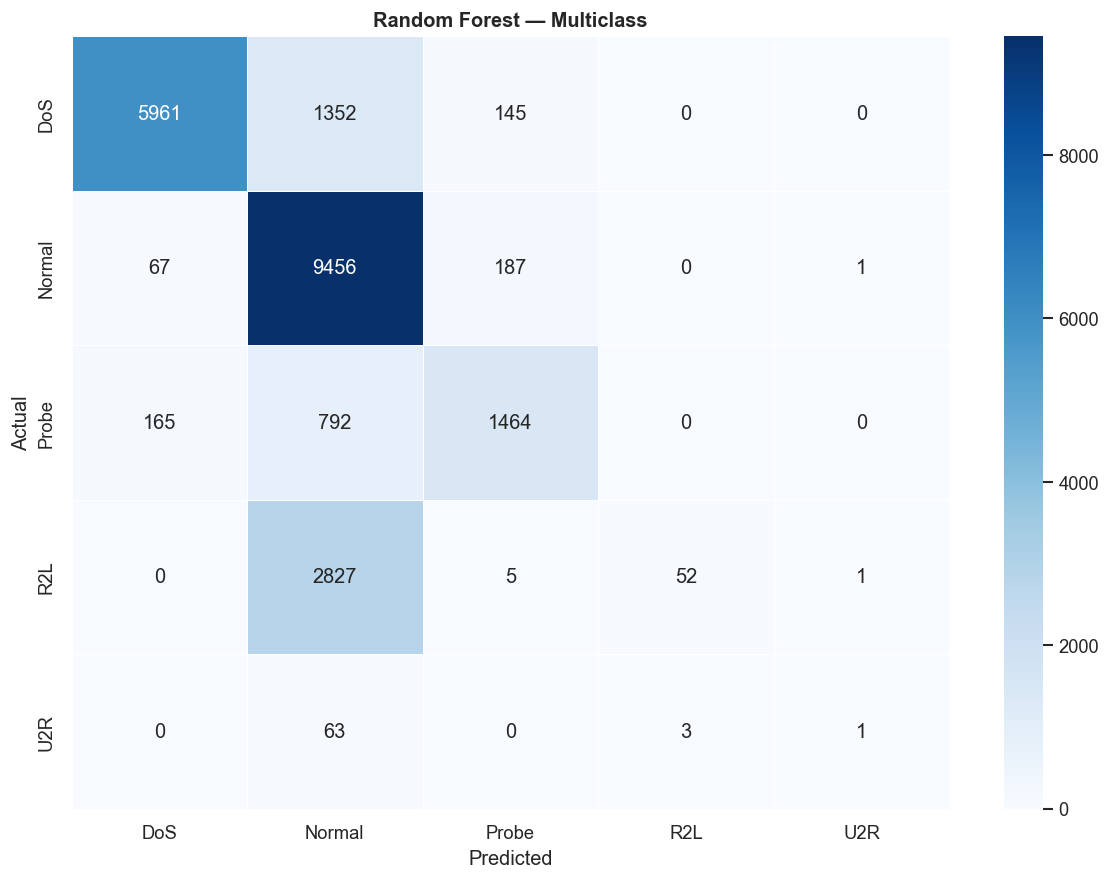

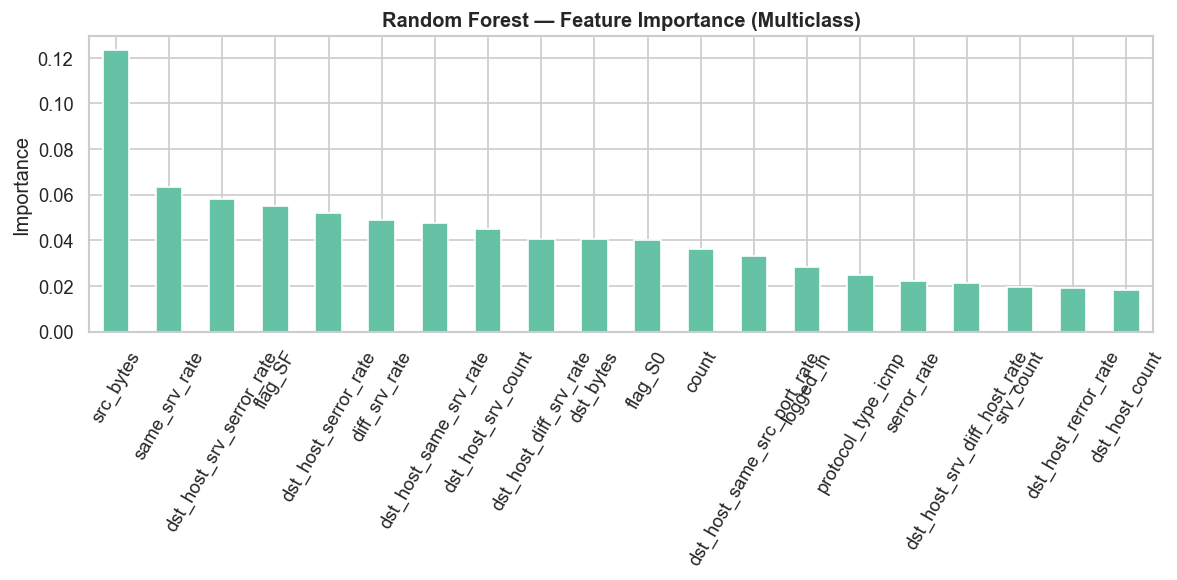

Saved: d:\projects\network-intrusion-detection-xai\results\models\random_forest_multiclass.pkl
Training XGBoost...

── XGBoost (multiclass) ──
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.81      0.64      0.71      2421
         R2L       0.98      0.12      0.21      2885
         U2R       0.76      0.19      0.31        67

    accuracy                           0.78     22542
   macro avg       0.84      0.55      0.59     22542
weighted avg       0.83      0.78      0.74     22542



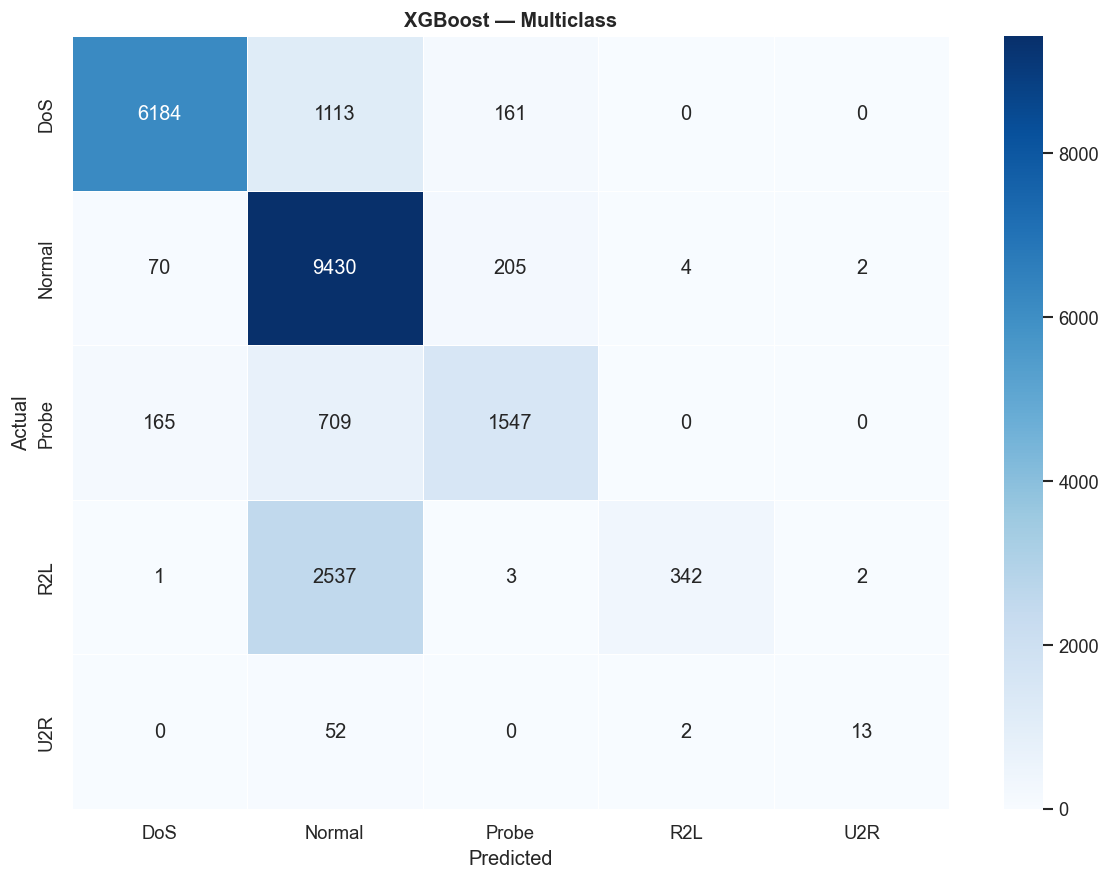

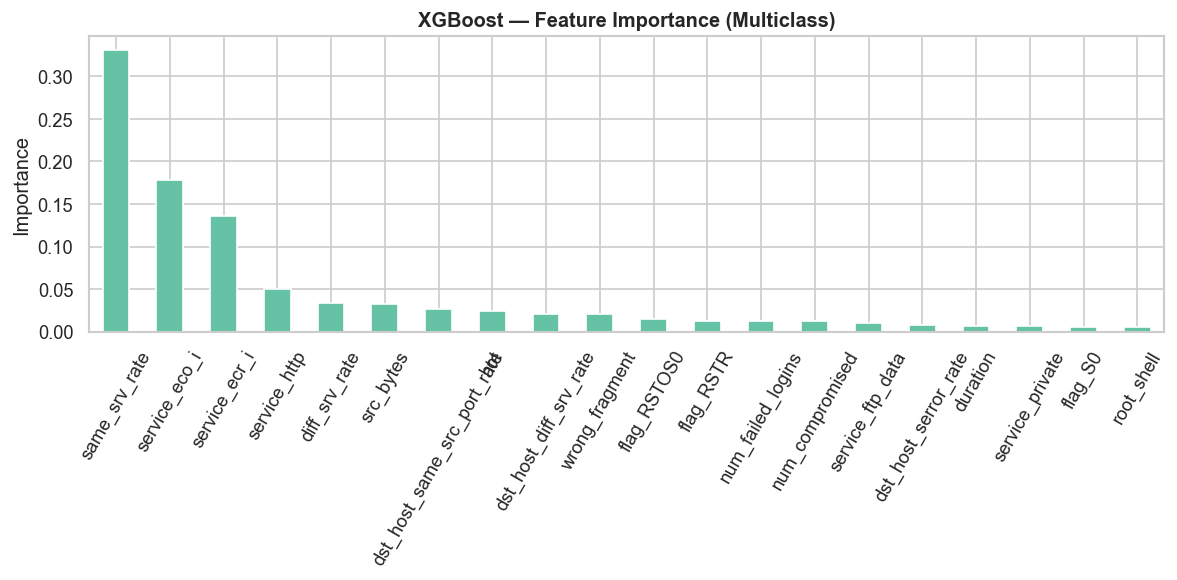

Saved: d:\projects\network-intrusion-detection-xai\results\models\xgboost_multiclass.pkl
Training Decision Tree...

── Decision Tree (multiclass) ──
              precision    recall  f1-score   support

         DoS       0.96      0.82      0.89      7458
      Normal       0.67      0.96      0.79      9711
       Probe       0.81      0.64      0.71      2421
         R2L       0.98      0.09      0.16      2885
         U2R       0.64      0.27      0.38        67

    accuracy                           0.77     22542
   macro avg       0.81      0.56      0.59     22542
weighted avg       0.82      0.77      0.73     22542



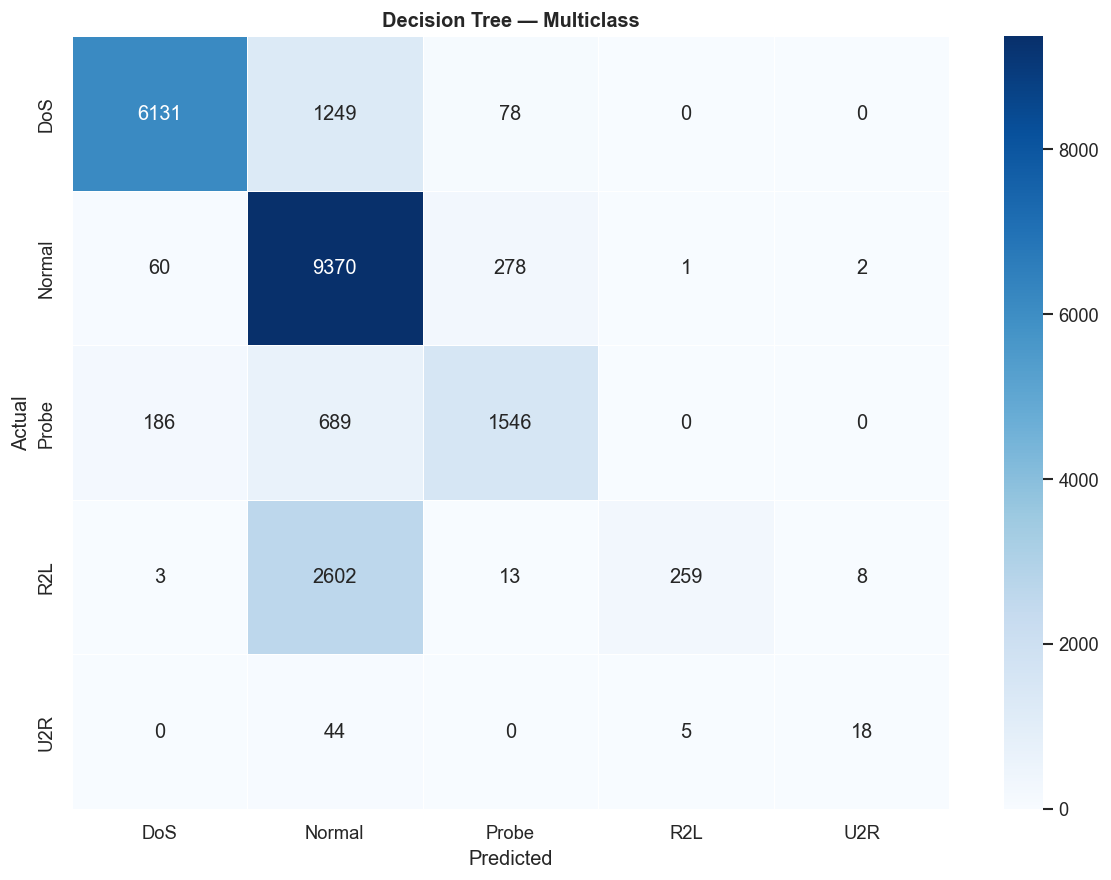

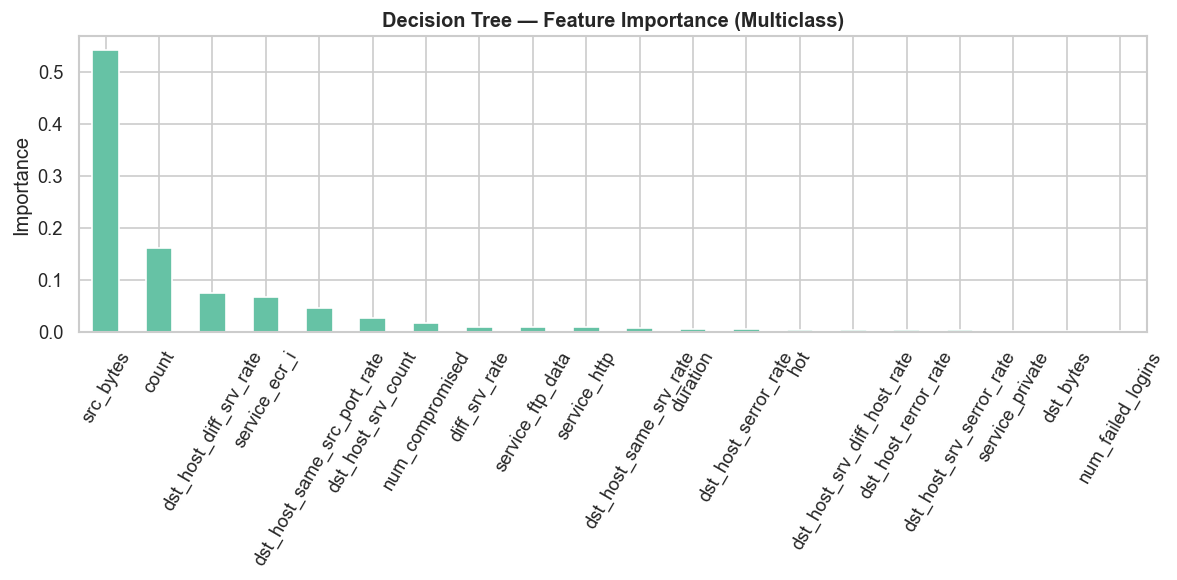

Saved: d:\projects\network-intrusion-detection-xai\results\models\decision_tree_multiclass.pkl
Training Logistic Regression...

── Logistic Regression (multiclass) ──
              precision    recall  f1-score   support

         DoS       0.93      0.85      0.88      7458
      Normal       0.67      0.93      0.78      9711
       Probe       0.85      0.73      0.79      2421
         R2L       0.47      0.04      0.07      2885
         U2R       0.70      0.31      0.43        67

    accuracy                           0.76     22542
   macro avg       0.72      0.57      0.59     22542
weighted avg       0.75      0.76      0.72     22542



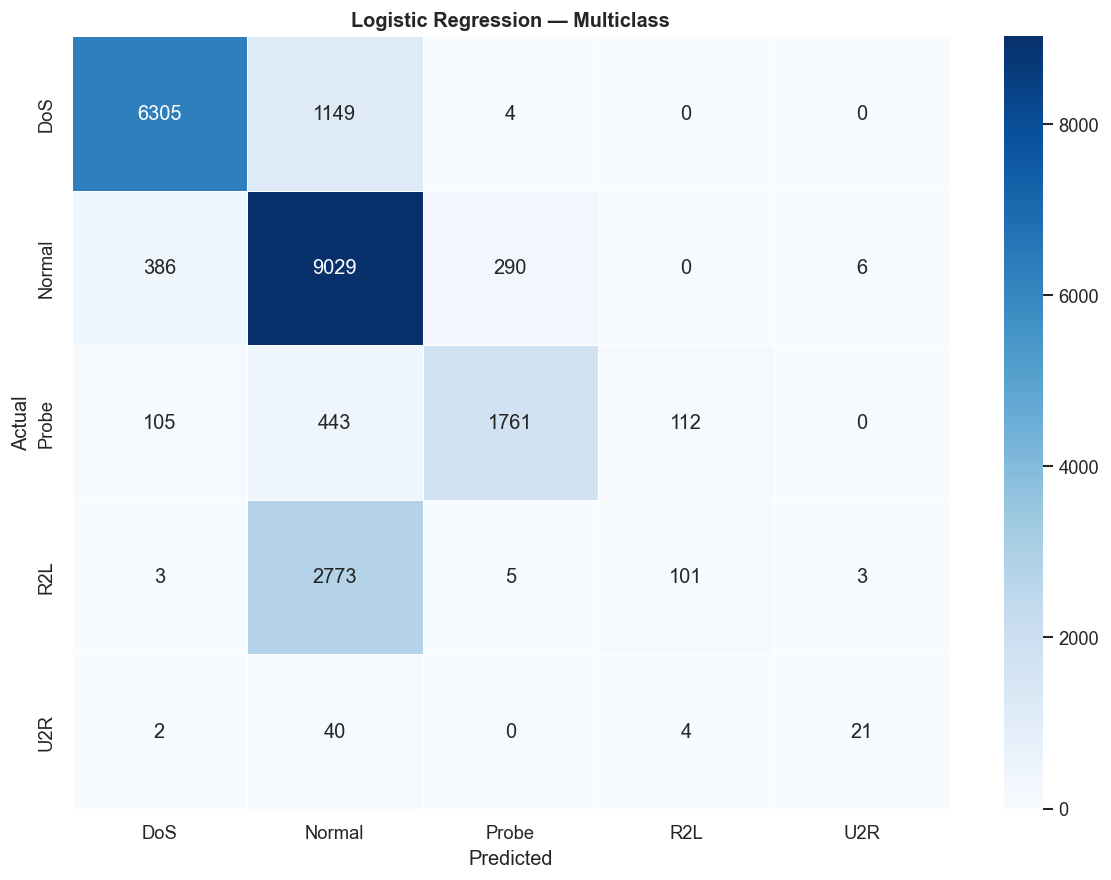

Saved: d:\projects\network-intrusion-detection-xai\results\models\logistic_regression_multiclass.pkl


In [7]:
ml_multi_results = []

ml_models_multi = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

for name, model in ml_models_multi.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_multi)
    y_pred = model.predict(X_test_multi)
    ml_multi_results.append(evaluate(name, y_test_multi, y_pred, CLASS_NAMES, 'multiclass'))
    save_cm(y_test_multi, y_pred, CLASS_NAMES, f'{name} — Multiclass',
            os.path.join(CM_DIR, f'cm_{name.lower().replace(" ","_")}_multiclass.png'))
    if hasattr(model, 'feature_importances_'):
        save_fi(model, FEATURE_COLS, f'{name} — Feature Importance (Multiclass)',
                os.path.join(FI_DIR, f'fi_{name.lower().replace(" ","_")}_multiclass.png'))
    save_model(model, f'{name.lower().replace(" ","_")}_multiclass')

---
## 7. DL Model — MLP (Binary + Multiclass)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,241 (290.00 KB)

 Trainable params: 73,473 (287.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9794 - loss: 0.0572 - val_accuracy: 0.9906 - val_loss: 0.0259
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9896 - loss: 0.0281 - val_accuracy: 0.9911 - val_loss: 0.0219
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9909 - loss: 0.0243 - val_accuracy: 0.9931 - val_loss: 0.0178
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0212 - val_accuracy: 0.9942 - val_loss: 0.0188
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.0209 - val_accuracy: 0.9945 - val_loss: 0.0173
Epoch 6/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9933 - loss: 0.0182 - val_accuracy: 0.9950 - val_loss: 0.0154
Epoch 7/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9935 - loss: 0.0179 - val_accuracy: 0.9953 - val_loss: 0.0147
Epoch 8/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9939 - loss: 0.0171 - val_accuracy: 0.

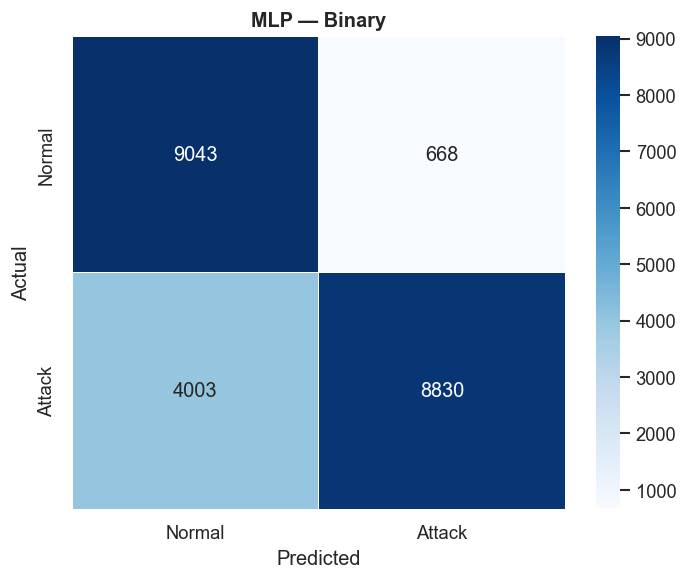

Saved: mlp_binary.keras


In [8]:
def build_mlp(input_dim, output_dim, output_activation, loss):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(output_dim, activation=output_activation),
    ])
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    return model

input_dim = X_train.shape[1]

# Binary MLP
mlp_bin = build_mlp(input_dim, 1, 'sigmoid', 'binary_crossentropy')
mlp_bin.summary()
hist_bin = mlp_bin.fit(X_train, y_train_bin, epochs=50, batch_size=256,
                        validation_split=0.1, callbacks=[ES], verbose=1)
mlp_bin_pred = (mlp_bin.predict(X_test) > 0.5).astype(int).flatten()
mlp_bin_metrics = evaluate('MLP', y_test_bin, mlp_bin_pred, BIN_CLASSES, 'binary')
save_cm(y_test_bin, mlp_bin_pred, BIN_CLASSES, 'MLP — Binary',
        os.path.join(CM_DIR, 'cm_mlp_binary.png'))
mlp_bin.save(os.path.join(MODEL_DIR, 'mlp_binary.keras'))
print('Saved: mlp_binary.keras')

Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9680 - loss: 0.1078 - val_accuracy: 0.9903 - val_loss: 0.0295
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0348 - val_accuracy: 0.9931 - val_loss: 0.0229
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9904 - loss: 0.0287 - val_accuracy: 0.9925 - val_loss: 0.0214
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9913 - loss: 0.0255 - val_accuracy: 0.9942 - val_loss: 0.0196
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0233 - val_accuracy: 0.9952 - val_loss: 0.0169
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step

── MLP (multiclass) ──
              precision    recall  f1-score   support

         DoS       0.88      0.85      0.86      7458
      Normal       0.69      0.93      0.79      9711
       Probe       0.83      0.66      0.74      2421
         R2L       0.93      0.08      0.14      2885
         U2R       0.5

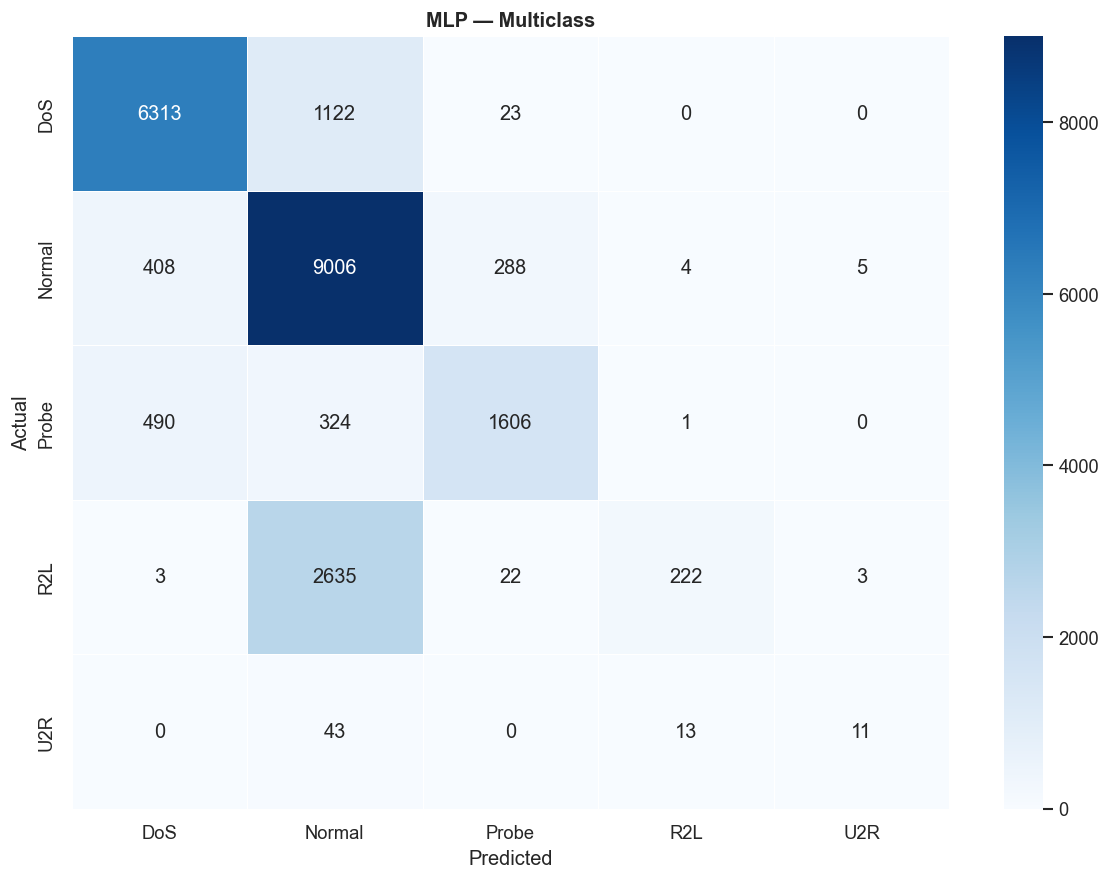

Saved: mlp_multiclass.keras


In [9]:
# Multiclass MLP
num_classes = len(CLASS_NAMES)
mlp_multi = build_mlp(input_dim, num_classes, 'softmax', 'sparse_categorical_crossentropy')
hist_multi = mlp_multi.fit(X_train, y_train_multi, epochs=50, batch_size=256,
                            validation_split=0.1, callbacks=[ES], verbose=1)
mlp_multi_pred = np.argmax(mlp_multi.predict(X_test_multi), axis=1)
mlp_multi_metrics = evaluate('MLP', y_test_multi, mlp_multi_pred, CLASS_NAMES, 'multiclass')
save_cm(y_test_multi, mlp_multi_pred, CLASS_NAMES, 'MLP — Multiclass',
        os.path.join(CM_DIR, 'cm_mlp_multiclass.png'))
mlp_multi.save(os.path.join(MODEL_DIR, 'mlp_multiclass.keras'))
print('Saved: mlp_multiclass.keras')

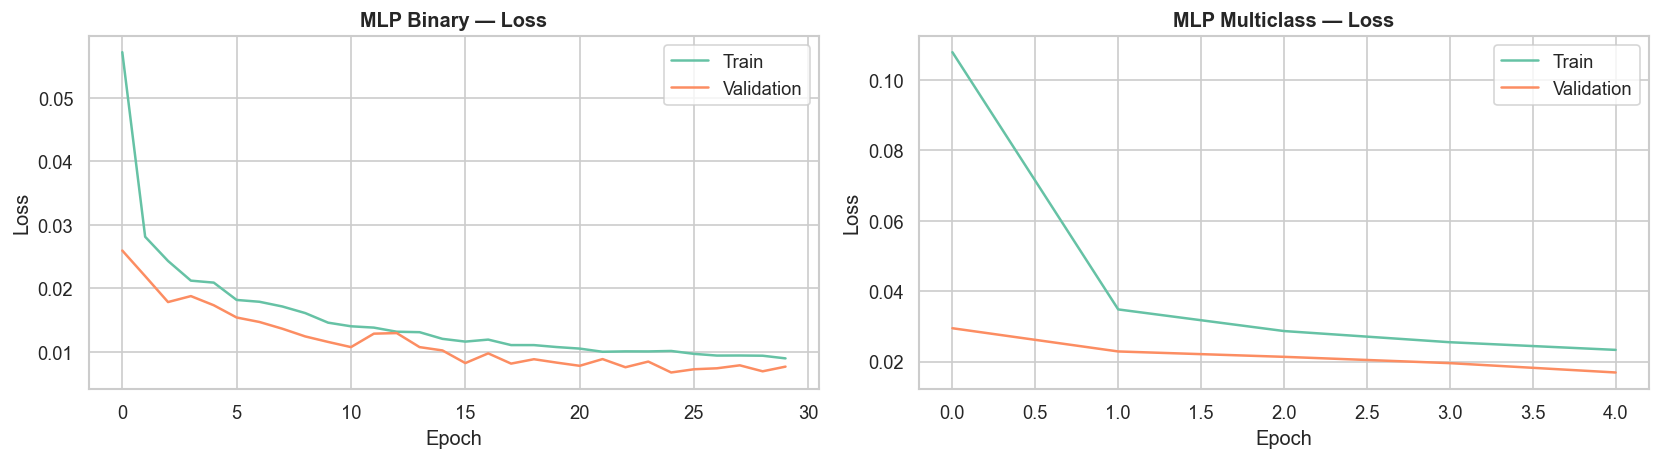

In [10]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, hist, title in zip(axes, [hist_bin, hist_multi], ['MLP Binary — Loss', 'MLP Multiclass — Loss']):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Validation')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'mlp_training_history.png'), bbox_inches='tight')
plt.show()

---
## 8. DL Model — Autoencoder (Anomaly Detection)

Trained on **normal traffic only**.  
High reconstruction error → anomaly (attack).

In [11]:
X_train_normal = X_train[y_train_bin == 0]
print(f'Normal training samples: {X_train_normal.shape[0]}')

def build_autoencoder(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.Dense(64,  activation='relu')(x)
    x   = layers.Dense(32,  activation='relu')(x)
    x   = layers.Dense(64,  activation='relu')(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    ae  = models.Model(inp, out, name='Autoencoder')
    ae.compile(optimizer='adam', loss='mse')
    return ae

ae = build_autoencoder(input_dim)
ae.summary()
hist_ae = ae.fit(X_train_normal, X_train_normal, epochs=50, batch_size=256,
                 validation_split=0.1, callbacks=[ES], verbose=1)

Normal training samples: 67343


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 122)            │        15,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,250 (204.10 KB)

 Trainable params: 52,250 (204.10 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3167 - val_loss: 0.1312
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1466 - val_loss: 0.0992
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1059 - val_loss: 0.0903
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0854 - val_loss: 0.0616
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1024 - val_loss: 0.0337


Threshold (95th pct): 0.288132

── Autoencoder (binary) ──
              precision    recall  f1-score   support

      Normal       0.64      0.92      0.76      9711
      Attack       0.91      0.61      0.73     12833

    accuracy                           0.74     22544
   macro avg       0.78      0.77      0.74     22544
weighted avg       0.79      0.74      0.74     22544



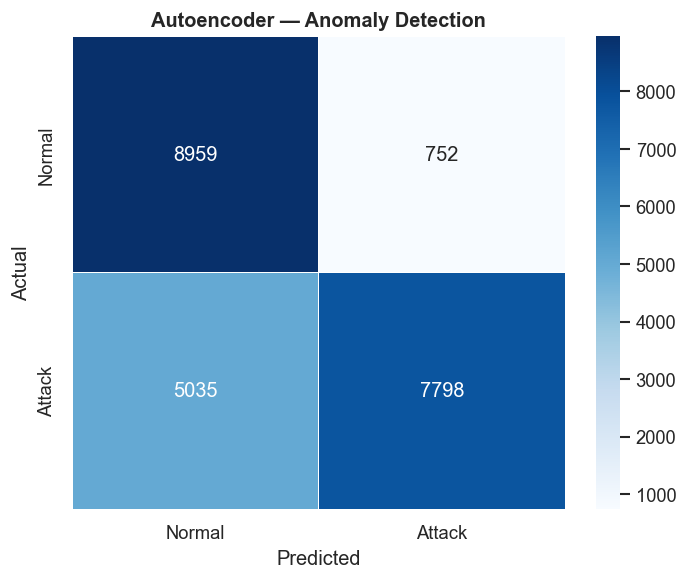

Saved: autoencoder.keras + ae_threshold.pkl


In [12]:
recon_normal  = ae.predict(X_train_normal, verbose=0)
errors_normal = np.mean(np.power(X_train_normal - recon_normal, 2), axis=1)
threshold     = np.percentile(errors_normal, 95)
print(f'Threshold (95th pct): {threshold:.6f}')

recon_test   = ae.predict(X_test, verbose=0)
errors_test  = np.mean(np.power(X_test - recon_test, 2), axis=1)
ae_pred      = (errors_test > threshold).astype(int)

ae_metrics = evaluate('Autoencoder', y_test_bin, ae_pred, BIN_CLASSES, 'binary')
save_cm(y_test_bin, ae_pred, BIN_CLASSES, 'Autoencoder — Anomaly Detection',
        os.path.join(CM_DIR, 'cm_autoencoder.png'))
ae.save(os.path.join(MODEL_DIR, 'autoencoder.keras'))
with open(os.path.join(MODEL_DIR, 'ae_threshold.pkl'), 'wb') as f: pickle.dump(threshold, f)
print('Saved: autoencoder.keras + ae_threshold.pkl')

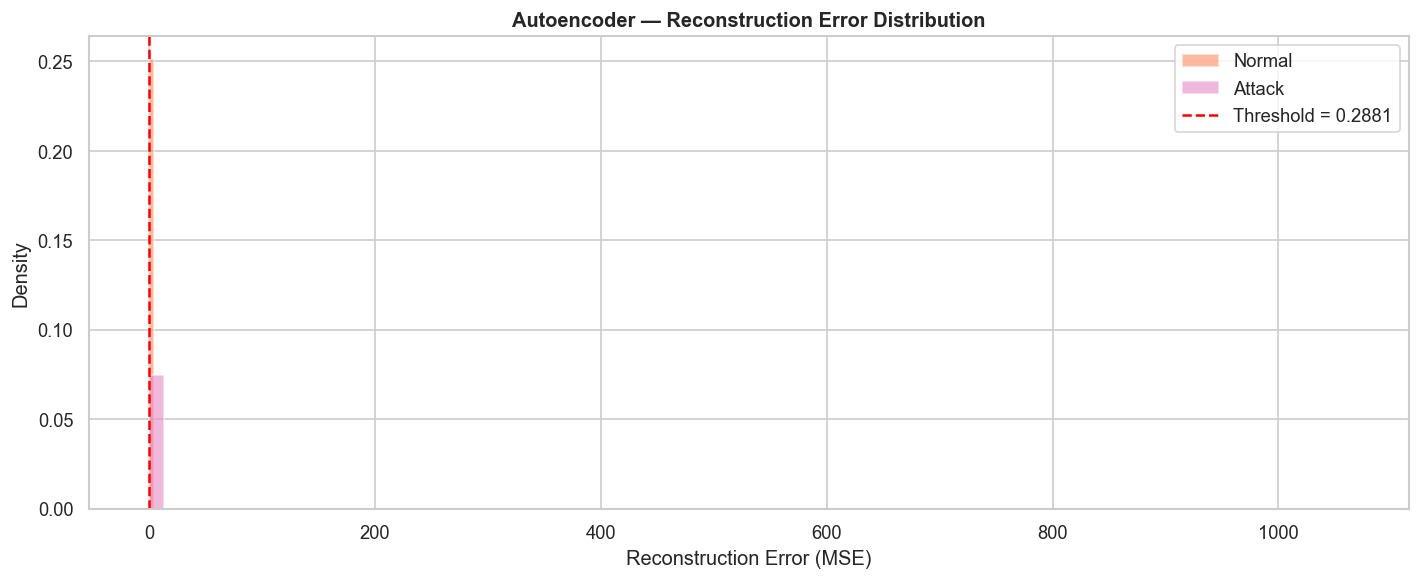

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(errors_test[y_test_bin==0], bins=80, alpha=0.6, label='Normal',
        color=sns.color_palette('Set2')[1], density=True)
ax.hist(errors_test[y_test_bin==1], bins=80, alpha=0.6, label='Attack',
        color=sns.color_palette('Set2')[3], density=True)
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)'); ax.set_ylabel('Density')
ax.set_title('Autoencoder — Reconstruction Error Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'ae_reconstruction_error.png'), bbox_inches='tight')
plt.show()

---
## 9. Results Comparison

=== BINARY CLASSIFICATION ===
                     Accuracy  Precision  Recall     F1
Model                                                  
Random Forest           76.48      96.70   60.75  74.62
XGBoost                 78.79      96.81   64.87  77.69
Decision Tree           79.15      96.56   65.71  78.21
Logistic Regression     75.35      91.73   62.32  74.21
MLP                     79.28      92.97   68.81  79.08
Autoencoder             74.33      91.20   60.77  72.94


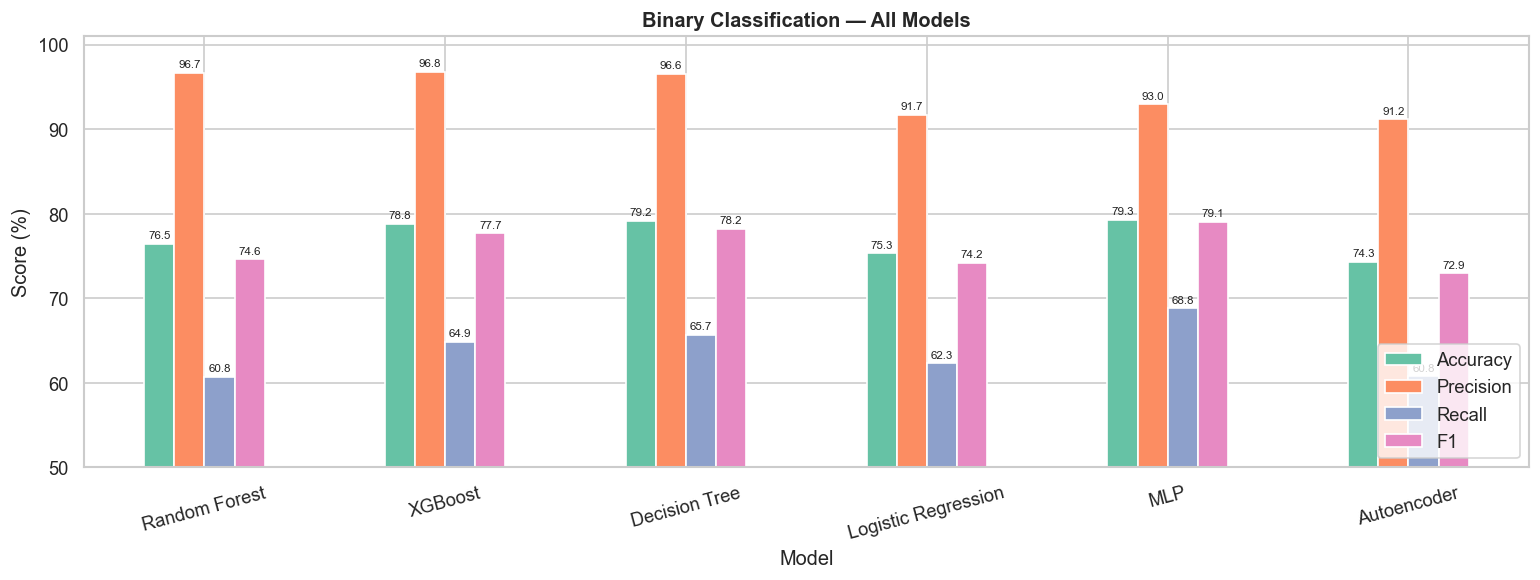

In [14]:
all_bin_results = ml_bin_results + [mlp_bin_metrics, ae_metrics]
df_bin = pd.DataFrame(all_bin_results).set_index('Model')
print('=== BINARY CLASSIFICATION ===')
print(df_bin.to_string())

ax = df_bin.plot(kind='bar', figsize=(13,5), color=sns.color_palette('Set2',4),
                  edgecolor='white', ylim=(50,101))
ax.set_title('Binary Classification — All Models', fontweight='bold')
ax.set_ylabel('Score (%)'); ax.tick_params(axis='x', rotation=15); ax.legend(loc='lower right')
for c in ax.containers: ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'binary_all_models_comparison.png'), bbox_inches='tight')
plt.show()

=== MULTICLASS CLASSIFICATION ===
                     Accuracy  Precision  Recall     F1
Model                                                  
Random Forest           75.12      80.89   75.12  70.47
XGBoost                 77.70      82.70   77.70  74.44
Decision Tree           76.85      82.09   76.85  73.31
Logistic Regression     76.38      74.97   76.38  72.27
MLP                     76.12      79.41   76.12  72.25


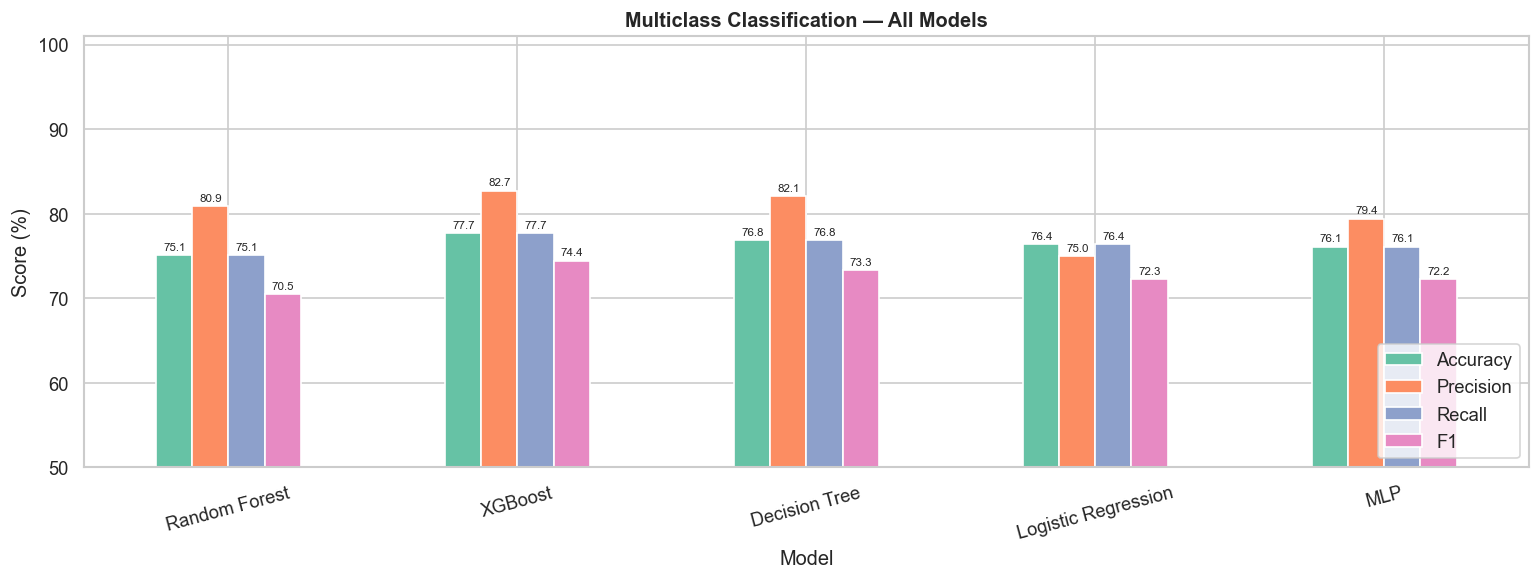

In [15]:
all_multi_results = ml_multi_results + [mlp_multi_metrics]
df_multi = pd.DataFrame(all_multi_results).set_index('Model')
print('=== MULTICLASS CLASSIFICATION ===')
print(df_multi.to_string())

ax = df_multi.plot(kind='bar', figsize=(13,5), color=sns.color_palette('Set2',4),
                    edgecolor='white', ylim=(50,101))
ax.set_title('Multiclass Classification — All Models', fontweight='bold')
ax.set_ylabel('Score (%)'); ax.tick_params(axis='x', rotation=15); ax.legend(loc='lower right')
for c in ax.containers: ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'multiclass_all_models_comparison.png'), bbox_inches='tight')
plt.show()

In [16]:
best_bin   = df_bin['F1'].idxmax()
best_multi = df_multi['F1'].idxmax()
print(f'Best Binary Model    : {best_bin} (F1 = {df_bin.loc[best_bin,"F1"]}%)')
print(f'Best Multiclass Model: {best_multi} (F1 = {df_multi.loc[best_multi,"F1"]}%)')

Best Binary Model    : MLP (F1 = 79.08%)
Best Multiclass Model: XGBoost (F1 = 74.44%)


---
## Checklist

| Model | Binary | Multiclass |
|-------|--------|------------|
| Random Forest | ✅ | ✅ |
| XGBoost | ✅ | ✅ |
| Decision Tree | ✅ | ✅ |
| Logistic Regression | ✅ | ✅ |
| MLP | ✅ | ✅ |
| Autoencoder | ✅ (anomaly) | — |